Importing Relevant Libraries

In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
from itertools import product

Data Collection and Preprocessing

In [3]:
data = pd.read_csv(r"C:\Users\jefft\Documents\Code Projects\Housing.csv")

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [5]:
data.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [6]:
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


We see from .info() that we do not have any null values.

If we needed to get rid of null values, we would use something like the .fillna() method to do so.

From the .info() method, we also see that we have 13 columns, with 7 of them being non numerical. 

Frst, we need to properly split the data and then standardize and normalize it.

In [7]:
features = data.drop(['price'], axis=1)
features


,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...
540,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,2910,3,1,1,no,no,no,no,no,0,no,furnished


This drops the price column from the data, allowing us to use everything else as the features.

In [8]:
label_enc = LabelEncoder()
features['airconditioning'] = label_enc.fit_transform(features['airconditioning'])
features['mainroad'] = label_enc.fit_transform(features['mainroad'])
features['guestroom'] = label_enc.fit_transform(features['guestroom'])
features['basement'] = label_enc.fit_transform(features['basement'])
features['hotwaterheating'] = label_enc.fit_transform(features['hotwaterheating'])
features['prefarea'] = label_enc.fit_transform(features['prefarea'])
features['furnishingstatus'] = label_enc.fit_transform(features['furnishingstatus'])
features


,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,7420,4,2,3,1,0,0,0,1,2,1,0
1,8960,4,4,4,1,0,0,0,1,3,0,0
2,9960,3,2,2,1,0,1,0,0,2,1,1
3,7500,4,2,2,1,0,1,0,1,3,1,0
4,7420,4,1,2,1,1,1,0,1,2,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
540,3000,2,1,1,1,0,1,0,0,2,0,2
541,2400,3,1,1,0,0,0,0,0,0,0,1
542,3620,2,1,1,1,0,0,0,0,0,0,2
543,2910,3,1,1,0,0,0,0,0,0,0,0


The encoder allows for us to change categorical data into numerical data, so it can properly be fed into the model.

In [9]:
target = data['price']
target

0      13300000
1      12250000
2      12250000
3      12215000
4      11410000
         ...   
540     1820000
541     1767150
542     1750000
543     1750000
544     1750000
Name: price, Length: 545, dtype: int64

In [10]:
scaler = StandardScaler()
features_normalized = scaler.fit_transform(features)
print(features_normalized)
print(features_normalized.shape)

[[ 1.04672629  1.40341936  1.42181174 ...  1.51769249  1.80494113
  -1.40628573]
 [ 1.75700953  1.40341936  5.40580863 ...  2.67940935 -0.55403469
  -1.40628573]
 [ 2.21823241  0.04727831  1.42181174 ...  1.51769249  1.80494113
  -0.09166185]
 ...
 [-0.70592066 -1.30886273 -0.57018671 ... -0.80574124 -0.55403469
   1.22296203]
 [-1.03338891  0.04727831 -0.57018671 ... -0.80574124 -0.55403469
  -1.40628573]
 [-0.5998394   0.04727831 -0.57018671 ... -0.80574124 -0.55403469
   1.22296203]]
(545, 12)


In [11]:
x = features_normalized
y = target.values.reshape(-1,1)
x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.3, random_state=1)
x_valid, x_test, y_valid, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=1)
print(x_train.shape,x_valid.shape, x_test.shape, y_train.shape, y_valid.shape, y_test.shape)

(381, 12) (82, 12) (82, 12) (381, 1) (82, 1) (82, 1)


In [12]:
class HouseDataSet(Dataset):
    def __init__(self,x,y):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.x)
    
    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]
 

In [13]:
train_dataset = HouseDataSet(x_train, y_train)
valid_dataset = HouseDataSet(x_valid, y_valid)
test_dataset = HouseDataSet(x_test, y_test)

In [14]:
parameters= {
    "batch": [16, 32, 64],
    "learning_rate": [0.001, 0.01, 0.1],
    "layer1": [64, 128],
    "layer2": [32, 64],
    "epochs": [100, 500]
}
parameters

{'batch': [16, 32, 64],
 'learning_rate': [0.001, 0.01, 0.1],
 'layer1': [64, 128],
 'layer2': [32, 64],
 'epochs': [100, 500]}

In [15]:
class PricePredict(nn.Module):
    def __init__ (self, input_size, layer1, layer2):
        super(PricePredict, self).__init__()
        self.linear1 = nn.Linear(input_size,layer1)
        self.linear2 = nn.Linear(layer1,layer2)
        self.linear3 = nn.Linear(layer2,1)

    def forward(self, x):
        x = torch.relu(self.linear1(x))
        x = torch.relu(self.linear2(x)) 
        x = torch.relu(self.linear3(x))
        return x


In [16]:
best_model = None
best_loss = float('inf')
best_params = None
input_size = x_train.shape[1]

In [17]:
for batch, learning_rate, layer1, layer2, epochs in product(
        parameters["batch"],
        parameters["learning_rate"],
        parameters["layer1"],
        parameters["layer2"],
        parameters["epochs"]):
     
     train_loader = DataLoader(train_dataset, batch_size=batch, shuffle= True)
     valid_loader = DataLoader(valid_dataset, batch_size=batch, shuffle=False)

     model = PricePredict(input_size, layer1, layer2)
     criterion = nn.MSELoss()
     optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

     for epoch in range(epochs):
          model.train()
          train_loss = 0.0
          for x_batch, y_batch in train_loader:
               optimizer.zero_grad()
               outputs = model(x_batch)
               loss = criterion(outputs, y_batch)
               loss.backward()
               optimizer.step()
               train_loss+=loss.item()
     model.eval()
     eval_loss = 0.0
     with torch.no_grad():
          for x_batch, y_batch in valid_loader:
              outputs = model(x_batch)
              loss = criterion(outputs, y_batch)
              eval_loss += loss.item()
     aver_eval_loss = eval_loss / len(valid_loader)
     print(f"Parameters: batch_size={batch}, lr={learning_rate}, layer1={layer1}, layer2={layer2}, epochs={epochs}, Training Loss={train_loss/len(train_loader):.3f}, Validation Loss={aver_eval_loss:.3f}")

     if aver_eval_loss < best_loss:
        best_loss = aver_eval_loss
        best_model = model
        best_parameter = (batch, learning_rate, layer1, layer2, epochs)
print(f"Best Parameters: batch_size={best_parameter[0]}, lr={best_parameter[1]}, layer1={best_parameter[2]}, layer2={best_parameter[3]}, epochs={best_parameter[4]}, Best Validation Loss={best_loss:.3f}")





Parameters: batch_size=16, lr=0.001, layer1=64, layer2=32, epochs=100, Training Loss=24041980734122.668, Validation Loss=30363781431296.000
Parameters: batch_size=16, lr=0.001, layer1=64, layer2=32, epochs=500, Training Loss=4065183432704.000, Validation Loss=4022426927104.000
Parameters: batch_size=16, lr=0.001, layer1=64, layer2=64, epochs=100, Training Loss=22189060390912.000, Validation Loss=27255465749162.668
Parameters: batch_size=16, lr=0.001, layer1=64, layer2=64, epochs=500, Training Loss=2711606487722.667, Validation Loss=2751403764394.667
Parameters: batch_size=16, lr=0.001, layer1=128, layer2=32, epochs=100, Training Loss=22710625370112.000, Validation Loss=28067471643989.332
Parameters: batch_size=16, lr=0.001, layer1=128, layer2=32, epochs=500, Training Loss=1746801677653.333, Validation Loss=1851512520704.000
Parameters: batch_size=16, lr=0.001, layer1=128, layer2=64, epochs=100, Training Loss=19210460375722.668, Validation Loss=23103344214016.000
Parameters: batch_size=

In [18]:
test_loader = DataLoader(test_dataset, batch_size=best_parameter[0], shuffle=False)
best_model.eval()
predicted_price = []
actual_price = []

In [19]:
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        predictions = best_model(x_batch).view(-1).numpy()
        actuals = y_batch.view(-1).numpy()
        predicted_price.extend(predictions)
        print(f"Prediction: {predicted_price}")
        actual_price.extend(actuals)
        print(f"Actual: {actual_price}")
 

Prediction: [6295456.5, 2513788.5, 5205055.5, 4344831.0, 4217483.0, 3681638.5, 6191941.5, 4502764.5, 5835352.0, 4986483.5, 5421629.5, 4283967.5, 3109468.5, 2916191.5, 3422696.2, 5154001.5, 4229412.5, 2788273.0, 6316489.5, 6137901.5, 6413545.5, 4313223.0, 5407353.5, 3176210.8, 7286177.5, 4742654.5, 3173064.5, 3749157.2, 4860383.5, 3881135.8, 6321736.5, 3281646.5, 3869224.5, 3097715.0, 3592409.8, 3808191.8, 5004841.0, 4118239.5, 2761476.8, 4292199.0, 2967580.5, 4473091.5, 4750092.0, 4689247.5, 4027463.5, 2800136.0, 3982912.0, 4766199.5, 3533280.5, 3282957.0, 8297850.0, 3277933.0, 3080191.0, 4313223.0, 3543395.8, 4006849.0, 5334212.5, 4109070.0, 3971707.0, 6419366.5, 6157737.5, 3035910.5, 3489754.0, 4157125.5]
Actual: [8120000.0, 4200000.0, 6629000.0, 4123000.0, 3640000.0, 3325000.0, 5950000.0, 4620000.0, 3570000.0, 6895000.0, 4193000.0, 3703000.0, 2940000.0, 1890000.0, 3220000.0, 5873000.0, 4830000.0, 2660000.0, 6650000.0, 5460000.0, 6930000.0, 3430000.0, 4760000.0, 3500000.0, 8400000.0,

In [20]:
predicted_price =np.array(predicted_price)
actual_price =np.array(actual_price)
r2 = r2_score(actual_price, predicted_price)
print(print(f"{r2:.3f}"))

0.640
None


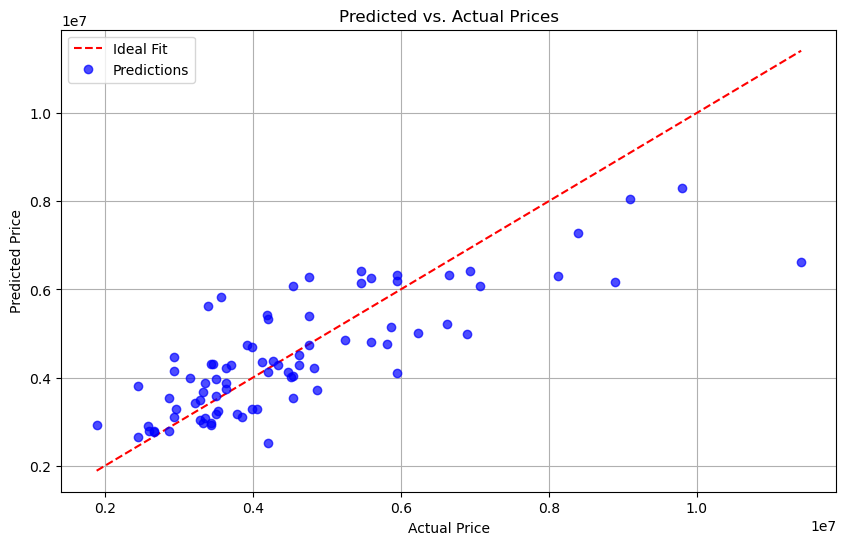

In [21]:
plt.figure(figsize=(10, 6))
plt.errorbar(actual_price, predicted_price, fmt='o', alpha=0.7, color='blue', ecolor='gray', elinewidth=1, capsize=3, label='Predictions')
plt.plot([min(actual_price), max(actual_price)], [min(actual_price), max(actual_price)], color='red', linestyle='--', label='Ideal Fit')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs. Actual Prices")
plt.grid(True)
plt.legend()
plt.show()

In [22]:
Results_table = pd.DataFrame({
    "Actual Price": actual_price,
    "Predicted Price": predicted_price,
    "Difference": actual_price-predicted_price,
    "% Difference": abs(((actual_price-predicted_price)/actual_price)*100)
})
Results_table = Results_table.astype(float)
Results_table =Results_table.round(3)
Results_table

,Actual Price,Predicted Price,Difference,% Difference
0,8120000.0,6295456.5,1824543.5,22.470
1,4200000.0,2513788.5,1686211.5,40.148
2,6629000.0,5205055.5,1423944.5,21.481
3,4123000.0,4344831.0,-221831.0,5.380
4,3640000.0,4217483.0,-577483.0,15.865
...,...,...,...,...
77,4760000.0,6284909.5,-1524909.5,32.036
78,11410000.0,6622584.5,4787415.5,41.958
79,2604000.0,2799784.5,-195784.5,7.519
80,4620000.0,4297543.0,322457.0,6.980


In [23]:
Results_table.describe()

,Actual Price,Predicted Price,Difference,% Difference
count,8.200000e+01,8.200000e+01,8.200000e+01,82.000000
mean,4.542659e+06,4.451141e+06,9.151753e+04,17.287976
std,1.798390e+06,1.323566e+06,1.075083e+06,14.245825
min,1.890000e+06,2.513788e+06,-2.265352e+06,0.218000
25%,3.368750e+06,3.317892e+06,-5.800964e+05,7.468750
50%,4.091500e+06,4.223448e+06,-4.103212e+04,13.479500
75%,5.407500e+06,5.301923e+06,6.053485e+05,22.438750
max,1.141000e+07,8.297850e+06,4.787416e+06,65.629000
